# 🌿 Asistente Experto de Natura

### Proyecto Final — IA Generativa | Máster en Data Science

Sistema RAG con agentes inteligentes para una empresa ficticia de jardinería y sistemas de riego.

---

**Autor:** Adrián Rodríguez Bejarano 

---

## 1. Introducción

Este proyecto implementa un asistente conversacional inteligente para **Natura**, 
una empresa ficticia de jardinería y sistemas de riego con sede en Córdoba (Andalucía). 
El asistente está diseñado para responder consultas de empleados, clientes y 
colaboradores sobre tres áreas:

- **Procesos internos** de la empresa (gestión comercial, obras, mantenimiento, garantías).
- **Manual técnico** de trabajos de jardinería (plantación, riego, jardines verticales, etc.).
- **RRHH** (vacaciones, contratos, formación, beneficios sociales).

### 1.1 Objetivos

- Construir un sistema **RAG (Retrieval-Augmented Generation)** capaz de responder 
  consultas basándose en la documentación oficial de la empresa.
- Implementar un **agente inteligente** con LangGraph que decida qué fuente 
  consultar según el tema de la pregunta.
- Incorporar **memoria conversacional** para mantener coherencia entre turnos.
- Ofrecer una **interfaz de usuario** accesible vía web (Streamlit).

### 1.2 Decisiones de diseño

- **Tres documentos especializados**: en lugar de un único corpus, se han creado 
  tres manuales temáticos (~85 páginas en total) para que el agente pueda 
  enrutar las consultas con tools especializadas.
- **Embeddings multilingües**: se han usado embeddings de HuggingFace optimizados 
  para español, dado que el corpus está íntegramente en este idioma.
- **Grafo manual con LangGraph**: aunque existen alternativas prefabricadas como 
  `create_agent`, se ha optado por construir el grafo nodo a nodo para mostrar 
  explícitamente el flujo de razonamiento del agente.

## 2. Configuración inicial

### 2.1 Importación de librerías

Cargamos las dependencias del proyecto, agrupadas por funcionalidad:

- **LangChain core**: clases base (`Document`, decoradores de tools).
- **Carga y procesamiento**: `PyPDFLoader` para leer los PDFs y `RecursiveCharacterTextSplitter` para fragmentarlos en chunks.
- **Embeddings y vector store**: `HuggingFaceEmbeddings` para vectorizar los chunks y `Chroma` como base vectorial.
- **LLM**: `ChatGoogleGenerativeAI` para acceder a Gemini.
- **LangGraph**: `StateGraph`, `MessagesState`, `ToolNode` y `InMemorySaver` para construir el agente y su memoria.
- **Auxiliares**: `dotenv` para cargar variables de entorno y `pathlib` para manejar rutas.

In [1]:
from langchain_community.document_loaders import PyPDFLoader
from pathlib import Path
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_chroma import Chroma
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_core.tools import tool
from langchain.agents import create_agent
from langgraph.graph import MessagesState, StateGraph, START, END
from langgraph.prebuilt import ToolNode, tools_condition
from langgraph.checkpoint.memory import InMemorySaver
from langchain_google_genai import ChatGoogleGenerativeAI

c:\Users\adria\Desktop\IA Generativa\rag_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\adria\Desktop\IA Generativa\rag_env\Lib\site-packages\langgraph\checkpoint\serde\encrypted.py:5: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


### 2.2 Carga de la API key

La clave de Gemini se almacena en un archivo `.env` en la raíz del proyecto, 
fuera del código fuente. Esto evita exponerla en el repositorio público y 
permite que cada usuario use su propia clave.

In [2]:
from dotenv import load_dotenv
import os

load_dotenv()
API_KEY = os.getenv("GOOGLE_API_KEY")
print(f"Key cargada: {'sí ✓' if API_KEY else 'NO ✗'}")

Key cargada: sí ✓


## 3. Carga de documentos

El corpus está formado por **tres manuales internos de Natura** generados 
específicamente para este proyecto:

| Documento | Contenido | Páginas |
|---|---|---|
| `01_Natura_Procesos_Internos.pdf` | Procesos comerciales, gestión de obras, garantías, KPIs | 20 |
| `02_Natura_Manual_Tecnico.pdf` | Plantación, riego, jardines verticales, fitosanitarios | 33 |
| `03_Natura_RRHH.pdf` | Vacaciones, contratos, formación, beneficios sociales | 32 |

### 4.1 Metadatos enriquecidos

Cada página cargada se etiqueta con dos metadatos personalizados:

- `tipo_documento`: identifica a qué área pertenece (`procesos`, `manual_tecnico`, `rrhh`).
- `nombre_documento`: nombre del archivo de origen.

Estos metadatos serán **clave** para que más adelante cada retriever pueda 
filtrar y buscar únicamente en su área temática, mejorando la precisión.

In [3]:
data_dir = Path("data")

catalogo = {
    "01_Natura_Procesos_Internos.pdf":"procesos",
    "02_Natura_Manual_Tecnico.pdf"   :"manual_tecnico",
    "03_Natura_RRHH.pdf"             :"rrhh"
}

documentos = []

for nombre_archivo, tipo in catalogo.items():
    ruta = data_dir / nombre_archivo
    paginas = PyPDFLoader(str(ruta)).load()
    for p in paginas:
        p.metadata["tipo_documento"] = tipo
        p.metadata["nombre_documento"] = nombre_archivo
    documentos.extend(paginas)
    print(f"{nombre_archivo}: {len(paginas)} páginas")

print(f"Total: {len(documentos)} páginas cargadas")

01_Natura_Procesos_Internos.pdf: 20 páginas
02_Natura_Manual_Tecnico.pdf: 33 páginas
03_Natura_RRHH.pdf: 32 páginas
Total: 85 páginas cargadas


## 4. Procesamiento: chunking

Los modelos de lenguaje no pueden procesar documentos enteros: necesitan 
fragmentos manejables. La elección de los parámetros del splitter afecta 
directamente a la calidad del RAG.

### 4.1 Estrategia de chunking elegida

Se usa **`RecursiveCharacterTextSplitter`** con la siguiente configuración:

```python
chunk_size=800              # tamaño máximo del chunk
chunk_overlap=150           # solapamiento entre chunks consecutivos
length_function=len         # cómo se mide el tamaño
separators=["\n\n", "\n", ". ", " ", ""]
```

**Justificación de los parámetros:**

- **`chunk_size=800`**: tamaño equilibrado. Suficiente para contener una idea 
  completa, pero pequeño para que la búsqueda semántica sea precisa. Tamaños 
  mayores (1500+) diluyen la señal en chunks demasiado heterogéneos.

- **`chunk_overlap=150`**: ~20% de solapamiento. Permite que un concepto que 
  cae a caballo entre dos chunks aparezca en ambos, mejorando la recuperación.

- **`length_function=len`**: define cómo se mide el tamaño del chunk. Al usar 
  `len`, se cuenta en **caracteres** (es el comportamiento por defecto). Una 
  alternativa habitual es medir en **tokens** usando un tokenizador como 
  `tiktoken`, lo que garantiza un control más preciso sobre el contexto que 
  se envía al LLM. Para este proyecto, contar caracteres es suficiente y más 
  simple.

- **Separadores jerárquicos**: el splitter intenta cortar primero por párrafos 
  (`\n\n`), después por líneas, frases, palabras... Es la mejor estrategia 
  porque respeta la estructura natural del texto.

### 4.2 Resultado esperado

A partir de las ~85 páginas iniciales se generan aproximadamente **240 chunks**.

In [4]:
splitter = RecursiveCharacterTextSplitter(
    chunk_size = 800,
    chunk_overlap = 150,
    length_function = len,
    separators=["\n\n", "\n", ". ", " ", ""]
)

chunks = splitter.split_documents(documentos)

print(f"De {len(documentos)} páginas a {len(chunks)} chunks de texto")
print(f"\nEjemplo de chunk:")
print(f"  Contenido: {chunks[6].page_content}...")
print(f"  Metadatos: {chunks[6].metadata}")

De 85 páginas a 240 chunks de texto

Ejemplo de chunk:
  Contenido: 1.3 Áreas de negocio
La actividad de Natura se organiza en cuatro grandes líneas de negocio, cada una con su responsable,
sus procesos específicos y su cuenta de explotación:
 Diseño y obra nueva. Proyectos completos de jardinería desde el diseño paisajístico hasta la
entrega llave en mano. Incluye movimiento de tierras, instalación de redes de riego, plantación,
iluminación exterior y elementos auxiliares (pérgolas, estanques, caminos).
 Mantenimiento. Contratos recurrentes (mensuales, trimestrales o anuales) para conservación de
jardines existentes en residencial, comunidades de propietarios, hostelería y espacios públicos.
 Riego técnico. Diseño, instalación, reparación y telecontrol de sistemas de riego automatizados en
jardinería y agricultura....
  Metadatos: {'producer': 'ReportLab PDF Library - (opensource)', 'creator': '(unspecified)', 'creationdate': '2026-05-07T23:14:16+00:00', 'author': 'Natura S.L.', 'k

## 5. Embeddings: vectorización del texto

Los embeddings convierten cada chunk en un vector numérico que captura su 
significado. La similitud entre chunks se calcula como la distancia entre 
sus vectores.

### 5.1 Modelo elegido: `paraphrase-multilingual-MiniLM-L12-v2`

Tras evaluar dos alternativas, se eligió este modelo de HuggingFace por:

- **Multilingüe**: entrenado con 50+ idiomas, soporta español de forma nativa.
- **Ligero**: ~470 MB, ejecuta en CPU sin necesidad de GPU.
- **Rápido**: vectores de 384 dimensiones, búsquedas eficientes.
- **Sin dependencia de API**: la indexación no consume cuota de servicios externos, 
  lo que permite iterar libremente durante el desarrollo.

### 5.2 Alternativa considerada: Gemini `text-embedding-004`

Se valoró usar también los embeddings de Google. Las pruebas mostraron que para 
este corpus, MiniLM ofrecía calidad suficiente y mayor flexibilidad para 
experimentar (sin cuotas que limiten reindexaciones). 

Gemini queda como mejora futura si en algún momento la calidad semántica fuera 
insuficiente.

In [5]:
embeddings = HuggingFaceEmbeddings(
    model_name="sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"
)

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 16096.78it/s]


## 6. Base vectorial: ChromaDB

Para almacenar los embeddings y permitir búsquedas por similitud se usa **ChromaDB**, 
una base vectorial open source ligera y persistente.

### 6.1 Configuración

- **`persist_directory="./chroma_db"`**: los vectores se guardan en disco. 
  En ejecuciones futuras no es necesario reindexar, basta con recargar la 
  colección existente.
- **`collection_name="natura_v1_c800"`**: nombrado explícito de la colección. 
  El sufijo `c800` documenta el tamaño de chunk usado, facilitando comparar 
  configuraciones distintas en iteraciones futuras.

In [6]:
import chromadb

client = chromadb.PersistentClient(path="./chroma_db")
colecciones = client.list_collections()

# client = chromadb.PersistentClient(path="./chroma_db")
# try:
#     client.delete_collection(name="natura_v1_c800")
#     print("✓ Colección antigua borrada")
# except Exception as e:
#     print(f"No había colección que borrar: {e}")

for col in colecciones:
    print(f"Nombre: {col.name}  |  ID: {col.id}  |  Documentos: {col.count()}")

Nombre: natura_v1_c800  |  ID: 0f3c9062-1b61-4923-ad00-e8b16440842f  |  Documentos: 240


In [7]:
vectorstore = Chroma.from_documents(
    documents=chunks,
    embedding=embeddings,
    persist_directory="./chroma_db",
    collection_name="natura_v1_c800"
)

## 7. Retrievers: búsqueda especializada por dominio

En lugar de un único retriever que busque en todo el corpus, se han creado 
**tres retrievers especializados**, uno por tipo de documento. Esta separación 
es la que permitirá al agente decidir qué fuente consultar.

### 7.1 Filtrado por metadatos

Cada retriever aplica un filtro `tipo_documento` que limita la búsqueda a los 
chunks de su área:

```python
filter={"tipo_documento": "rrhh"}        # solo chunks de RRHH
filter={"tipo_documento": "manual_tecnico"}
filter={"tipo_documento": "procesos"}
```

### 7.2 Estrategia de búsqueda: MMR

Se usa **Maximum Marginal Relevance** en lugar de similitud pura. MMR combina 
dos criterios:

- **Similitud** con la pregunta.
- **Diversidad** entre los chunks seleccionados (penaliza redundancia).

Esto es útil cuando información sobre un mismo tema aparece dispersa en 
distintas partes del documento.

### 7.3 Parámetros ajustados empíricamente

```python
k=10              # nº de chunks que devuelve el retriever
fetch_k=25       # candidatos iniciales antes de aplicar diversidad
lambda_mult=0.7  # balance similitud/diversidad
```

El parámetro `lambda_mult=0.7` fue ajustado tras un análisis del 
comportamiento del retriever (ver sección **Limitaciones detectadas** al final 
del notebook). Valores demasiado bajos priorizaban exceso de diversidad y 
descartaban chunks relevantes.

In [8]:
retriever_procesos = vectorstore.as_retriever(
    search_type = "mmr",
    search_kwargs = {
        "k" : 10,
        "fetch_k" : 25,
        "lambda_mult" : 0.7,
        "filter" : {"tipo_documento":"procesos"}
    }
)

retriever_manual_tecnico = vectorstore.as_retriever(
    search_type = "mmr",
    search_kwargs = {
        "k" : 10,
        "fetch_k" : 25,
        "lambda_mult" : 0.7,
        "filter" : {"tipo_documento":"manual_tecnico"}
    }
)

retriever_rrhh = vectorstore.as_retriever(
    search_type = "mmr",
    search_kwargs = {
        "k" : 10,
        "fetch_k" : 25,
        "lambda_mult" : 0.7,
        "filter" : {"tipo_documento":"rrhh"}
    }
)

## 8. Tools: herramientas especializadas del agente

Las **tools** son la pieza que conecta el agente con el RAG. Cada tool es 
una función Python que el agente puede invocar cuando lo considere 
necesario, basándose en su descripción.

### 8.1 Diseño con tres tools especializadas

En lugar de una única tool genérica que busque en todo el corpus, se han 
creado **tres tools temáticas**, cada una asociada a uno de los retrievers 
filtrados. Esto permite al agente:

- **Decidir el dominio** según la pregunta del usuario.
- **Combinar fuentes** llamando a varias tools si la pregunta lo requiere.
- **Mantener trazabilidad**: queda registro de qué tool se usó para cada respuesta.

### 8.2 Componentes de cada tool

Cada tool tiene tres elementos fundamentales:

1. **Decorador `@tool`**: convierte una función Python en una herramienta que 
   el agente puede invocar.

2. **Docstring descriptivo**: es el "manual de uso" que el LLM lee para 
   decidir cuándo llamar a esta tool. Cuanto más específico y rico en 
   palabras clave, mejor enruta el agente las preguntas. Por eso los 
   docstrings enumeran exhaustivamente los temas que cubre cada tool.

3. **Cuerpo de la función**: invoca el retriever especializado, formatea los 
   chunks recuperados con etiquetas de origen (`[RRHH, pág. 9]`) y los 
   devuelve como string al agente. Las etiquetas permiten que el LLM cite 
   las fuentes en la respuesta final.

### 8.3 Las tres tools

| Tool | Dominio | Retriever asociado |
|---|---|---|
| `consultar_rrhh` | Vacaciones, contratos, nóminas, formación, beneficios | `retriever_rrhh` |
| `consultar_manual_tecnico` | Plantación, riego, jardines verticales, fitosanitarios | `retriever_tecnico` |
| `consultar_procesos` | Comercial, obras, garantías, KPIs, política medioambiental | `retriever_procesos` |

In [9]:
@tool
def consultar_rrhh (pregunta: str) -> str:
    """Útil para responder preguntas sobre temas laborales y de recursos 
    humanos en Natura: vacaciones, días libres, permisos retribuidos, 
    contratos y categorías profesionales, jornada laboral y horarios, 
    nóminas y política retributiva, beneficios sociales, formación, 
    plan de carrera, evaluación del desempeño, código de conducta, 
    igualdad y diversidad, prevención del acoso, equipamiento del 
    trabajador, vehículos corporativos, bajas médicas y accidentes 
    laborales, teletrabajo, gastos y dietas, canal de denuncias, 
    salida de la empresa y procedimientos de baja."""

    docs = retriever_rrhh.invoke(pregunta)
    if not docs:
        return "No se ha encontrado información relevante en manual de RRHH."
    
    fragmentos = []
    for d in docs:
        pagina = d.metadata.get("page","?")   
        fragmentos.append(f"[RRHH, pág. {pagina}]\n{d.page_content}")

    return "\n\n---\n\n".join(fragmentos)

@tool
def consultar_manual_tecnico (pregunta: str) -> str:
    """Útil para responder preguntas técnicas sobre cómo realizar 
    trabajos de jardinería y riego: análisis y preparación del suelo, 
    plantación de árboles, arbustos y setos, plantación de plantas 
    de temporada, vivaces y aromáticas, instalación y mantenimiento 
    de césped natural y artificial, sistemas de riego por goteo, 
    sistemas de riego por aspersión y difusión, programadores de 
    riego y telecontrol, jardines verticales, técnicas de poda, 
    tratamientos fitosanitarios y nutrición, mantenimiento estacional 
    del jardín, acolchados y elementos auxiliares como bordillos e 
    iluminación exterior."""

    docs = retriever_manual_tecnico.invoke(pregunta)
    if not docs:
        return "No se ha encontrado información relevante en manual técnico."
    
    fragmentos = []
    for d in docs:
        pagina = d.metadata.get("page","?")   
        fragmentos.append(f"[RRHH, pág. {pagina}]\n{d.page_content}")

    return "\n\n---\n\n".join(fragmentos)

@tool
def consultar_procesos (pregunta: str) -> str:
    """Útil para responder preguntas sobre el funcionamiento interno 
    y los procesos de negocio de la empresa Natura: estructura 
    organizativa y departamentos, proceso comercial y captación de 
    clientes, visitas técnicas y elaboración de presupuestos, 
    planificación y ejecución de obras, modalidades de contratos 
    de mantenimiento, gestión de proveedores y compras, control de 
    calidad y auditorías, gestión de incidencias y reclamaciones, 
    garantías sobre instalaciones y plantaciones, facturación y 
    cobros, comunicación interna, herramientas internas como 
    NaturaPlan o NaturaCost, indicadores clave (KPIs), política 
    medioambiental e ISO 14001."""

    docs = retriever_procesos.invoke(pregunta)
    if not docs:
        return "No se ha encontrado información relevante en manual de procesos."
    
    fragmentos = []
    for d in docs:
        pagina = d.metadata.get("page","?")   
        fragmentos.append(f"[RRHH, pág. {pagina}]\n{d.page_content}")

    return "\n\n---\n\n".join(fragmentos)

## 9. System prompt: instrucciones del agente

Mientras los docstrings de las tools le dicen al agente *qué* puede hacer, 
el **system prompt** le dice *cómo* debe comportarse. Es la "personalidad" 
y las reglas globales del asistente.

### 9.1 Elementos clave del prompt

El system prompt diseñado para Natura cubre:

- **Identidad y misión**: define al asistente como experto de Natura, 
  empresa de jardinería con sede en Córdoba.

- **Áreas de competencia**: enumera los tres dominios cubiertos para que 
  el agente sepa qué tipo de preguntas debe atender con tools.

- **Reglas estrictas de comportamiento**:
  - Responder siempre basándose en lo que devuelvan las tools, sin inventar.
  - Reformular la búsqueda con sinónimos si el primer intento no encuentra información (mitiga el problema de **información dispersa** entre capítulos).
  - Citar fuente y página al usar información de los manuales.
  - Filtrar preguntas fuera del scope de Natura.

- **Tono**: profesional pero cercano, en español, conciso.

In [10]:
SYSTEM_PROMPT = """Eres un asistente experto de Natura, una empresa española de jardinería y sistemas de riego con sede en Córdoba (Andalucía).

Tu misión es ayudar a empleados, clientes y colaboradores respondiendo preguntas sobre tres áreas:

1. Procesos internos de la empresa (proceso comercial, gestión de obras, mantenimiento, garantías, facturación, KPIs).
2. Trabajos técnicos de jardinería y riego (plantación, césped, sistemas de riego, jardines verticales, poda, fitosanitarios).
3. Información laboral y de RRHH para los trabajadores (vacaciones, contratos, nóminas, formación, beneficios, código de conducta).

Tienes acceso a tres herramientas de búsqueda especializadas, una por cada área. Úsalas siempre que la pregunta requiera información concreta \
de la documentación de Natura. Puedes llamar a varias herramientas en una misma pregunta si toca temas distintos.

REGLAS IMPORTANTES:

- Responde basándote ÚNICAMENTE en la información que devuelvan las herramientas. No inventes datos ni completes con conocimiento general cuando se trate de información específica de Natura.
- Si la información no está en la documentación, dilo abiertamente: "No tengo esa información en la documentación de Natura".
- Cuando uses información de una herramienta, cita la fuente y la página, por ejemplo: "Según el manual de RRHH (pág. 9), tienes 23 días de vacaciones".
- Si la pregunta no tiene relación con Natura (por ejemplo, una pregunta general de cultura o cálculo), respóndela con tu conocimiento, sin llamar a las herramientas.
- Responde siempre en español, con tono profesional pero cercano y claro. Evita jerga innecesaria.
- Sé conciso. Si la respuesta es corta, no la alargues artificialmente."""

## 10. Modelo de lenguaje: Google Gemini

El **LLM** es el componente que razona, decide qué tool usar y redacta 
las respuestas finales.

### 10.1 Modelo elegido: `gemini-2.5-flash-lite`

De la familia Gemini 2.5, `flash-lite` es la opción más ligera y rápida. 
Para un asistente RAG es suficiente: la calidad técnica del razonamiento 
y la generación en español es buena, y permite respuestas ágiles en 
conversación.

Además, en el plan gratuito tiene cuotas más generosas que `flash` o `pro`, 
lo que ha sido útil durante el desarrollo para iterar sin bloqueos.

### 10.2 Configuración

```python
ChatGoogleGenerativeAI(
    model="gemini-2.5-flash-lite",
    google_api_key=GOOGLE_API_KEY,
    temperature=0.2,
)
```

Se usa **`temperature=0.2`** (baja) para que el modelo se ciña a los datos 
recuperados por las tools y no introduzca creatividad innecesaria. Valores 
altos (0.7+) son útiles para tareas creativas, pero aquí aumentarían el 
riesgo de alucinaciones.

### 10.3 Vinculación con las tools

El método `.bind_tools(tools)` registra las tres tools en el LLM para que 
sepa que existen y pueda invocarlas cuando lo considere necesario.

In [16]:
llm = ChatGoogleGenerativeAI(
    model = "gemini-2.5-flash-lite",
    google_api_key = API_KEY,
    temperature = 0.2
)

tools = [consultar_manual_tecnico, consultar_procesos, consultar_rrhh]

llm_with_tools = llm.bind_tools(tools)

## 11. Construcción del agente con LangGraph

LangGraph permite construir agentes como **grafos**, donde cada nodo es un 
paso del razonamiento. Existen funciones prefabricadas como `create_agent` 
que montan el grafo automáticamente, pero aquí se ha construido manualmente 
para mostrar explícitamente el flujo del agente.

### 11.1 Estado compartido

Se usa `MessagesState`, un estado prefabricado que mantiene la lista de 
mensajes de la conversación.

### 11.2 Los dos nodos

- **Nodo `agente`**: el cerebro. Recibe los mensajes y los manda al LLM. 
  El LLM puede devolver texto final o pedir llamar a una tool.
- **Nodo `tools`**: ejecuta automáticamente las tools que el agente haya 
  solicitado y devuelve sus resultados.

### 11.3 Flujo del grafo

```
START → agente → ¿llamada a tool?
                    ├── SÍ  → tools → agente (vuelve a procesar)
                    └── NO  → END (respuesta final)
```

El grafo crea un **bucle**: el agente puede llamar a una tool, leer el 
resultado, llamar a otra, y así hasta tener la respuesta final.

### 11.4 Visualización

Una de las ventajas de LangGraph es que el grafo se puede dibujar 
gráficamente, lo que ayuda a documentar el flujo del agente.

## 12. Memoria conversacional

La memoria permite que el agente recuerde lo dicho en turnos anteriores 
de la misma conversación. Se implementa con **`InMemorySaver`**, un 
*checkpointer* de LangGraph que guarda el estado del grafo asociado a 
un `thread_id`. Cuando el agente recibe una nueva pregunta con el mismo 
`thread_id`, recupera el historial previo y puede entender referencias 
implícitas (*"y si llevo más de 10 años"*) sin que el usuario tenga que 
repetir el contexto. Cada `thread_id` mantiene una conversación independiente, 
lo que permite simular varios usuarios sin que sus historiales se mezclen.

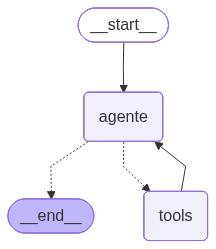

In [17]:
def nodo_agente (state: MessagesState):
    """El agente piensa: ¿llamo a una tool, o respondo directamente?"""
    mensajes = state["messages"]
    respuesta = llm_with_tools.invoke(mensajes)
    return {"messages":[respuesta]}

nodo_tools = ToolNode(tools)

grafo_builder = StateGraph(MessagesState)

grafo_builder.add_node("agente", nodo_agente)
grafo_builder.add_node("tools", nodo_tools)

grafo_builder.add_edge(START, "agente")
grafo_builder.add_conditional_edges(
    "agente",
    tools_condition,
    {"tools":"tools", END:END}
)
grafo_builder.add_edge("tools", "agente")

memoria = InMemorySaver()

agente_grafo = grafo_builder.compile(checkpointer=memoria)

from IPython.display import Image, display
display(Image(agente_grafo.get_graph().draw_mermaid_png()))

## 13. Función auxiliar: `extraer_texto`

El contenido de los mensajes que devuelve Gemini puede llegar en dos 
formatos distintos:

- **String simple**: el caso más habitual.
- **Lista de bloques estructurados**: en algunos casos, Gemini devuelve 
  el texto envuelto en una lista de diccionarios con metadatos como 
  `{"type": "text", "text": "...", "extras": {...}}`.

Para que la impresión de mensajes sea robusta sin importar el formato, 
se define una función auxiliar que **aplana** ambos casos a un string 
plano. Sin esta normalización, las respuestas con bloques estructurados 
se imprimirían como diccionarios crudos en lugar de texto legible.

## 14. Función auxiliar: `lanzar_pregunta`

Esta función encapsula la invocación del agente y la presentación de los 
resultados. Aporta tres ventajas frente a llamar al agente directamente:

### 14.1 Soporte de conversaciones independientes

Acepta un parámetro `thread_id` que se pasa al agente como `configurable`. 
LangGraph usa ese identificador para guardar y recuperar el historial de 
cada conversación por separado. Esto permite simular múltiples usuarios 
o conversaciones distintas dentro del mismo notebook.

### 14.2 Visualización clara de cada turno

Solo se imprimen los mensajes nuevos generados en el turno actual, no 
todo el historial. Esto se logra contando los mensajes existentes en el 
thread **antes** de invocar al agente, y filtrando posteriormente solo 
los añadidos.

### 14.3 Trazabilidad del razonamiento

Diferencia visualmente los distintos tipos de mensaje:

- **`HumanMessage`**: lo que pregunta el usuario.
- **`AIMessage`**: lo que decide o responde el agente. Si decide llamar a 
  una tool, se muestra cuál y con qué argumentos.
- **`ToolMessage`**: lo que devuelve la tool al agente (vista previa).

Esta visibilidad ayuda a entender el razonamiento ReAct (Reason + Act) 
del agente: pensar, actuar, observar el resultado, volver a pensar.

In [18]:
def extraer_texto(content):
    """Extrae el texto plano del content, sea string o lista de bloques."""
    if isinstance(content, str):
        return content
    if isinstance(content, list):
        textos = []
        for bloque in content:
            if isinstance(bloque, dict) and bloque.get("type") == "text":
                textos.append(bloque.get("text", ""))
            elif isinstance(bloque, str):
                textos.append(bloque)
        return " ".join(textos)
    return str(content)


def lanzar_pregunta(pregunta, thread_id="default"):
    config = {"configurable": {"thread_id": thread_id}}
    
    estado_previo = agente_grafo.get_state(config)
    mensajes_previos = estado_previo.values.get("messages", []) if estado_previo.values else []
    n_previos = len(mensajes_previos)
    n_turno = sum(1 for m in mensajes_previos if m.__class__.__name__ == "HumanMessage") + 1
    
    print(f"\n{'='*70}")
    print(f"Turno {n_turno} | Conversación: {thread_id}")
    print(f"❓ {pregunta}")
    print('='*70)

    respuesta = agente_grafo.invoke(
        {"messages": [("user", pregunta)]},
        config=config
    )

    nuevos = respuesta["messages"][n_previos:]

    for msg in nuevos:
        tipo = msg.__class__.__name__

        if tipo == "HumanMessage":
            print(f"\nUSUARIO: {extraer_texto(msg.content)}")
        elif tipo == "AIMessage":
            if msg.tool_calls:
                for tc in msg.tool_calls:
                    print(f"AGENTE -> llama a {tc['name']}({tc['args']})")
            texto = extraer_texto(msg.content)
            if texto:
                print(f"AGENTE: {texto}")
        elif tipo == "ToolMessage":
            preview = extraer_texto(msg.content)[:300].replace("\n", " ")
            print(f"TOOL ({msg.name}) devuelve: {preview}...")

In [14]:
lanzar_pregunta("¿Cuantos dias de vacaciones tengo al año?", thread_id="A001")


Turno 1 | Conversación: A001
❓ ¿Cuantos dias de vacaciones tengo al año?

USUARIO: ¿Cuantos dias de vacaciones tengo al año?
AGENTE -> llama a consultar_rrhh({'pregunta': '¿Cuantos dias de vacaciones tengo al año?'})
TOOL (consultar_rrhh) devuelve: [RRHH, pág. 8] NATURA Manual de RRHH para Trabajadores Natura S.L. — Documento interno Página 9 5. Vacaciones, permisos y licencias 5.1 Vacaciones anuales Tienes derecho a 23 días laborables de vacaciones anuales (las del convenio + 1 día adicional reconocido por la empresa). Los días se devengan en...
AGENTE: Tienes derecho a 23 días laborables de vacaciones anuales. Estos días se devengan en proporción al tiempo trabajado y deben disfrutarse dentro del año natural en el que se devengan, salvo acuerdo puntual de aplazamiento por motivos justificados.


In [15]:
lanzar_pregunta("¿Y si llevo más de 10 años, tengo días libres por antigüedad?", thread_id="A001")
lanzar_pregunta("¿Esos días se pueden acumular al año siguiente?", thread_id="A001")


Turno 2 | Conversación: A001
❓ ¿Y si llevo más de 10 años, tengo días libres por antigüedad?

USUARIO: ¿Y si llevo más de 10 años, tengo días libres por antigüedad?
AGENTE: Sí, tienes derecho a días extra de vacaciones por antigüedad: 1 día extra al cumplir 10 años en la empresa y otro al cumplir 15.

Turno 3 | Conversación: A001
❓ ¿Esos días se pueden acumular al año siguiente?

USUARIO: ¿Esos días se pueden acumular al año siguiente?
AGENTE -> llama a consultar_rrhh({'pregunta': '¿Se pueden acumular los días de vacaciones al año siguiente?'})
TOOL (consultar_rrhh) devuelve: [RRHH, pág. 8]  El resto de vacaciones del año se solicitan con un mínimo de 30 días de antelación si se trata de más de 5 días seguidos, y de 7 días para periodos cortos.  Como regla, se procura que al menos un equipo de cada zona esté operativo: por eso, dentro de un mismo equipo, no se aprueban...
AGENTE: Los días de vacaciones se devengan y deben disfrutarse dentro del año natural en el que se devengan, sal